In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import dotenv_values
from pymongo import MongoClient

db = MongoClient(dotenv_values("../../.env.development")["DB_CONNECTION_STRING"])["chungus"]

In [2]:
runs = pd.DataFrame(db.botruns.find(
    {"policyId": {"$in": ["heuristic-v2", "learned-v1"]}, "outcome": {"$in": ["win", "dead"]}},
    {"_id": 0, "batchId": 1, "policyId": 1, "policyVersion": 1, "archetypeId": 1, "wins": 1, "outcome": 1},
))
runs["arm"] = runs.policyId + " " + runs.policyVersion
runs.groupby(["arm", "batchId"]).wins.agg(["count", "mean"]).round(2)

count  mean
arm                batchId                                          
heuristic-v2 2.0.0 f8207bc3-bade-4eeb-a7be-43e0085609a1      3  6.00
heuristic-v2 2.1.0 1ad4d818-036f-4785-b1d0-4ff78c43ceb4     30  5.67
                   c43f5e1b-0d69-482e-9dcb-c85fc707fe2c     10  5.80
learned-v1 1.0.0   00fc1e21-3a94-4881-9649-d4d1e9cac925     10  7.00

In [3]:
learned   = runs[runs.batchId == "00fc1e21-3a94-4881-9649-d4d1e9cac925"]
heuristic = runs[runs.batchId == "c43f5e1b-0d69-482e-9dcb-c85fc707fe2c"]
print("learned  ", sorted(learned.wins))
print("heuristic", sorted(heuristic.wins))
print("full wins:", learned.outcome.eq("win").sum(), "vs", heuristic.outcome.eq("win").sum())

learned   [3, 3, 5, 5, 6, 7, 7, 10, 12, 12]
heuristic [2, 4, 5, 5, 5, 5, 5, 6, 9, 12]
full wins: 2 vs 1


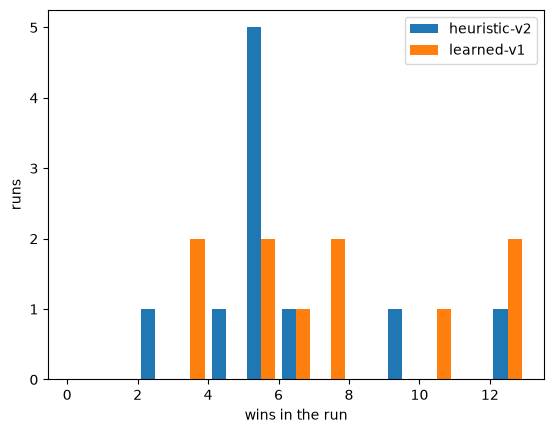

In [4]:
plt.hist([heuristic.wins, learned.wins], bins=range(0, 14), label=["heuristic-v2", "learned-v1"])
plt.xlabel("wins in the run"); plt.ylabel("runs"); plt.legend(); plt.show()

In [5]:
rng = np.random.default_rng(0)

def bootstrap_difference(old, new, n=10_000):
    old, new = np.asarray(old), np.asarray(new)
    diffs = [rng.choice(new, len(new)).mean() - rng.choice(old, len(old)).mean() for _ in range(n)]
    return np.percentile(diffs, [2.5, 50, 97.5])

low, middle, high = bootstrap_difference(heuristic.wins, learned.wins)
print(f"learned minus heuristic: {middle:+.2f} wins (95% interval {low:+.2f} to {high:+.2f})")

learned minus heuristic: +1.20 wins (95% interval -1.40 to +3.70)


In [6]:
spread = np.sqrt((learned.wins.var() + heuristic.wins.var()) / 2)
for n in [10, 30, 50, 100]:
    print(f"{n:>3} runs per arm -> interval is roughly ±{1.96 * spread * np.sqrt(2 / n):.2f} wins")

 10 runs per arm -> interval is roughly ±2.69 wins
 30 runs per arm -> interval is roughly ±1.55 wins
 50 runs per arm -> interval is roughly ±1.20 wins
100 runs per arm -> interval is roughly ±0.85 wins


In [7]:
heuristic_all = runs[runs.arm == "heuristic-v2 2.1.0"]
print(len(heuristic_all), "heuristic runs")
bootstrap_difference(heuristic_all.wins, learned.wins).round(2)

40 heuristic runs


array([-0.77,  1.27,  3.45])